# Problem 6 - Phase Identification(2)

## Agenda
- Problem Description
- Problem Implementation
- Wrap-Up

## Problem Description
- <b>Consider a grid for which we do not have sufficient metering data $z_{meter}$ and estimate the state vector $x$ that fully characterizes the condition in which the grid is operated,given the grid static information of its structure and corresponding component models, and the standard measurement values of all grid connected loads.
    
    -<b>Let us use the four-bus radial feeder system of the previous example and assume we have access to real-time voltage measurements on bus k (as before). Assuming pseudo-measurements on per-phase load currents are available, we want to estimate the remaining feeder bus voltages.

Considered network
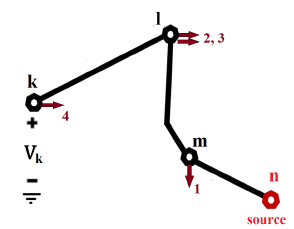

<b>Import Python Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Parameters

In [2]:
cosPhi=0.95
#time=48
m=12
netFactor=0.25
#noiseFactor=0.005

<b>Initial data

In [3]:
#Consumption dataset
s=  [[0.0450,    0.0150,    0.0470,    0.0330],
     [0.0250,    0.0150,    0.2480,    0.0330],
     [0.0970,    0.0250,    0.3940,    0.0330],
     [0.0700,    0.0490,    0.0200,    0.4850],
     [0.1250,    0.0460,    0.0160,    0.1430],
     [0.2900,    0.0270,    0.0160,    0.0470],
     [0.2590,    0.0150,    0.0170,    0.0200],
     [0.2590,    0.0160,    0.0280,    0.0160],
     [0.4420,    0.0160,    0.0500,    0.0170],
     [0.2010,    0.0230,    0.0460,    0.0160],
     [0.2060,    0.0490,    0.0220,    0.0240],
     [0.1300,    0.0470,    0.0160,    0.0490],
     [0.0460,    0.0260,    0.0170,    0.0480]]
s = np.array(s)

#topology
topo=[[1, 2],[2,3],[3,4]]
nBUS=np.max(topo)

#Impedance
z=np.multiply([complex(0.1,0.05),complex(0.15,0.07),complex(0.2,0.1)],netFactor)

vr=1 #Reference voltage
el=1
ni=20 #Iterations for the Power Flow




<b>Power Flow Function

In [4]:
def pf3ph(t,z,si,vr,el,ni,al):
    #Matrices creation
    t=np.array(t)
    p=t[:,0]
    f=t[:,1]
    w=len(p)+1
    vp=np.zeros((nBUS-1,w), dtype=complex)
    vn=np.zeros((nBUS-1,w), dtype=complex)
    vp[0,0:w]=vr
    
    for h in range (2,nBUS):
        vp[h-1,:]=vp[h-2,:]*al  #Create a three phase system of voltages
                                #Voltages will be the same in all BUS

    va=vp-vn                                                      #Auxiliar voltage
    ia=np.conj(np.divide(np.multiply(si,np.abs(va)**el),va))      #Auxiliar current 
    
    for it in range(ni):                                          #Iterations of Power Flow
        va=vp-vn
        ip=np.conj(np.divide(np.multiply(si,np.abs(va)**el),va))  #Phase current 
        inn=-np.sum(ip,0)                                         #Neutral current 

        for k in range(w-1,0,-1):                                 #Backward Cycle
            n=f[k-1]
            m=p[k-1]
            ip[:,m-1]=ip[:,m-1]+ip[:,n-1]                         #Phase Current
            inn=-np.sum(ip,0)                                     #Neutral Current

        eps= np.linalg.norm(np.max(np.abs(ia-ip),0))              #Error, comparing the new currents and the old ones (previous iteration)

        if eps>1e-4:
            ia=ip
            mvp=0
            mvn=0
            eps=np.inf
        else:                       #If the error is lower than the limit, we can return the results 
            mvp=(vp-vn)             #Phase Voltages to return
            mvn=vn[0,:]             #Neutral Voltage to return
#            return mvp, mvn, eps, ip, inn;
            return mvp, ip;
        for k in range (w-1):                     #Forward Cycle
            n=f[k]                                
            m=p[k]
            vn[:,n-1]=vn[:,m-1]-z[k]*inn[n-1]     #Neutral Voltage 
            vp[:,n-1]=vp[:,m-1]-z[k]*ip[:,n-1]    #Phase Voltage
        ia=ip             #Save the current of previous iteration

<b>Compute the values of voltages in function of currents

In [5]:
al=np.exp(np.multiply(np.multiply(complex(0,-1),2/3),np.pi)) #Phase Angle
sp=np.mean(s[0:m,:], axis=0) #Average power in each phase (i0)

si=[[0, 0, sp[2], 0],[0, 0, sp[1], 0],[0, sp[0],  0, sp[3]]] #Power in each bus and in each phase

mvp, ip=pf3ph(topo,z,si,vr,el,ni,al)  #Compute the power flow

zv=mvp[:,3]    #Voltage Measurement in Node 4 

print('The values of the currents are:\n',ip)

The values of the currents are:
 [[ 0.07666399-0.00064047j  0.07666399-0.00064047j  0.07666399-0.00064047j
   0.        -0.j        ]
 [-0.0141556 -0.02483195j -0.0141556 -0.02483195j -0.0141556 -0.02483195j
  -0.        +0.j        ]
 [-0.12640751+0.22194277j -0.12640751+0.22194277j -0.03759005+0.06643618j
  -0.03759005+0.06643618j]]


<b>State Estimation
   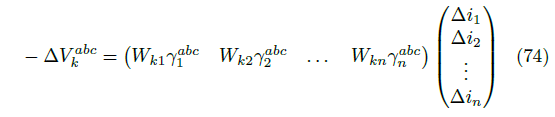
    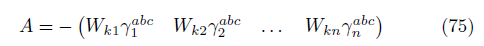
    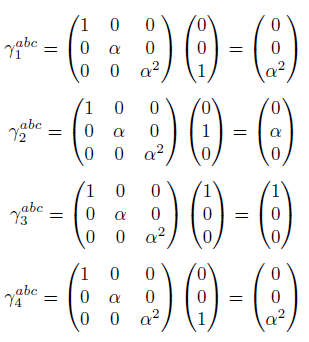
    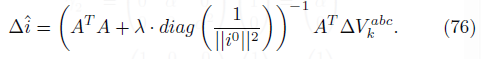

In [6]:
 
W = np.array([[2, 1, 1],
              [1, 2, 1],
              [1, 1, 2]])

gamma = np.zeros((3, 4), dtype=complex)
gamma[:, 0] = [0,         0,         al**2]   
gamma[:, 1] = [0,         al,        0    ]   
gamma[:, 2] = [1,         0,         0    ]   
gamma[:, 3] = [0,         0,         al**2]   
 

z_k = [z[0], z[0]+z[1], z[0]+z[1], z[0]+z[1]+z[2]]


A = np.zeros((3, 4), dtype=complex)
for j in range(4):
    A[:, j] = -z_k[j] * W @ gamma[:, j]
 
print('\nMatrix A:\n', A)
 
# Tikhonov regularisation matrix

lam = 1e-9
rho = np.diag(1.0 / np.abs(sp))
rhoTrho = rho.T @ rho
 
ds = s[0:m, :] - sp
dx = np.zeros((4, m), dtype=complex)
 
for i in range(m):
    # Power for this time period
    si_t = [
        [0, 0,       s[i, 2], 0       ],   # phase a
        [0, 0,       s[i, 1], 0       ],   # phase b
        [0, s[i, 0], 0,       s[i, 3] ],   # phase c
    ]
 
    # Run power flow for this period to get actual voltages
    mvp_t, ip_t = pf3ph(topo, z, si_t, vr, el, ni, al)
 
    # Voltage at monitored bus (bus 4) for this period
    zv_t = mvp_t[:, 3]
 
    # Voltage variation
    dv = (zv_t - zv)
 
    # Regularised least-squares solution
    AtA = A.conj().T @ A
    Atdv = A.conj().T @ dv
    dx[:, i] = np.linalg.solve(AtA + lam * rhoTrho, Atdv)
 
    # min-norm solution for comparison:
    dx[:, i] = A.conj().T @ np.linalg.solve(A @ A.conj().T, dv)
 
print('\nPseudo-measurements i0:\n', sp)
print('\nEstimated current deviations Δî (columns = time periods):\n', dx)


Matrix A:
 [[ 0.02332532-0.01540064j  0.00526924+0.06912659j -0.125     -0.06j
   0.1038814 -0.06992786j]
 [ 0.02332532-0.01540064j  0.01053848+0.13825318j -0.0625    -0.03j
   0.1038814 -0.06992786j]
 [ 0.04665064-0.03080127j  0.00526924+0.06912659j -0.0625    -0.03j
   0.20776279-0.13985572j]]

Pseudo-measurements i0:
 [0.17908333 0.02858333 0.07666667 0.07633333]

Estimated current deviations Δî (columns = time periods):
 [[-1.55740806e-02+2.50433062e-04j -1.65228338e-02+3.59231721e-04j
  -1.31064825e-02+4.41683276e-04j  8.14992587e-02-6.35696006e-03j
   1.15978269e-02-5.75803241e-04j -9.73099528e-04-3.45234921e-06j
  -8.18287443e-03+1.72947747e-04j -9.03310152e-03+1.96470686e-04j
  -1.37058192e-04+4.48080883e-05j -1.17852900e-02+2.40538784e-04j
  -9.84762713e-03+1.83694684e-04j -8.13989949e-03+1.08088575e-04j]
 [-1.35828979e-02-1.46683654e-04j -1.35833422e-02-2.74708903e-04j
  -3.58476244e-03-4.64353900e-04j  2.03930304e-02+1.37723869e-03j
   1.74148339e-02+2.98648877e-04j -1.5840

<b>Graphics

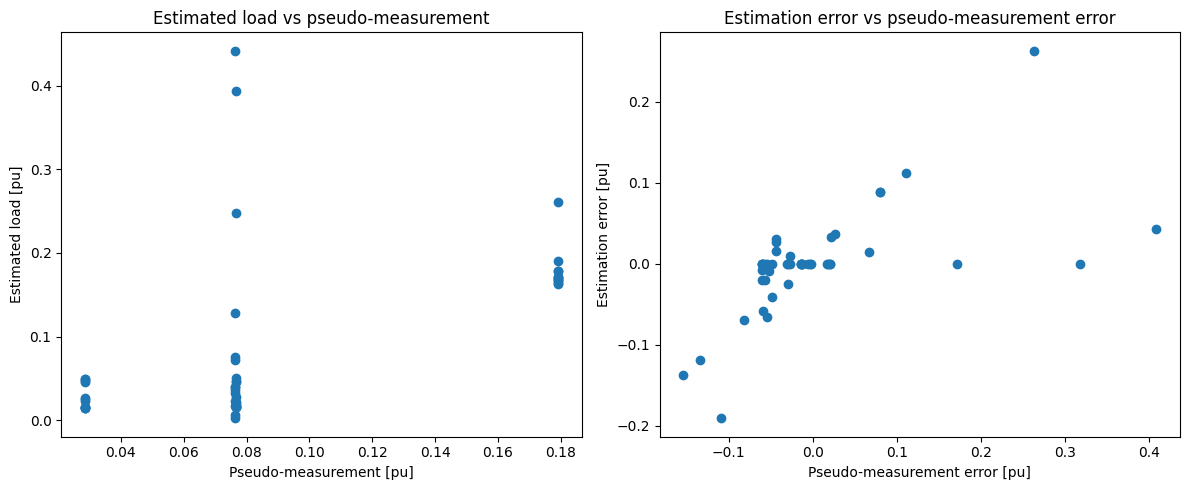

In [7]:

# yy1: pseudo-measurement values
# yy2: estimated actual currents
# yy3: true deviations
# yy4: estimation error
yy1 = sp                       
yy2 = sp + np.real(dx).T        
yy3 = ds                        
yy4 = ds - np.real(dx).T 
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
for i in range(m):
    axes[0].plot(yy1, yy2[i, :], 'C0o')
axes[0].set_xlabel('Pseudo-measurement [pu]')
axes[0].set_ylabel('Estimated load [pu]')
axes[0].set_title('Estimated load vs pseudo-measurement')
 
for i in range(m):
    axes[1].plot(yy3[i, :], yy4[i, :], 'C0o')
axes[1].set_xlabel('Pseudo-measurement error [pu]')
axes[1].set_ylabel('Estimation error [pu]')
axes[1].set_title('Estimation error vs pseudo-measurement error')
 
plt.tight_layout()
plt.show()

In [8]:
print("sp (pseudo-measurements):", sp)
print("\nA matrix:\n", A)
print("\nFor period 0:")
print("  zv (reference voltage):", zv)
print("  zv_t (real-time voltage):", mvp_t[:,3])  # run this inside the loop for i=0
print("  dv:", dv)
print("  dx[:,0]:", dx[:,0])
print("  s[0,:] (true loads):", s[0,:])

sp (pseudo-measurements): [0.17908333 0.02858333 0.07666667 0.07633333]

A matrix:
 [[ 0.02332532-0.01540064j  0.00526924+0.06912659j -0.125     -0.06j
   0.1038814 -0.06992786j]
 [ 0.02332532-0.01540064j  0.01053848+0.13825318j -0.0625    -0.03j
   0.1038814 -0.06992786j]
 [ 0.04665064-0.03080127j  0.00526924+0.06912659j -0.0625    -0.03j
   0.20776279-0.13985572j]]

For period 0:
  zv (reference voltage): [ 1.00256392-0.01072892j -0.49248567-0.87251786j -0.48057951+0.84937025j]
  zv_t (real-time voltage): [ 1.00631448-0.00319825j -0.49244873-0.86549546j -0.48460471+0.85781421j]
  dv: [ 3.75055991e-03+0.00753067j  3.69381063e-05+0.0070224j
 -4.02519898e-03+0.00844396j]
  dx[:,0]: [-0.01557408+0.00025043j -0.0135829 -0.00014668j -0.02966431+0.00046458j
 -0.0697819 +0.00049898j]
  s[0,:] (true loads): [0.045 0.015 0.047 0.033]


In [9]:
rms_pm  = np.sqrt(np.mean(yy3**2, axis=0))
rms_est = np.sqrt(np.mean(yy4**2, axis=0))
improvement = (1 - rms_est/rms_pm) * 100

print("\nRMS error of pseudo-measurements:", rms_pm)
print("RMS error of estimates:", rms_est)
print("Improvement over pseudo-measurements:", improvement, "%")


RMS error of pseudo-measurements: [0.11586519 0.01412125 0.11392858 0.12760834]
RMS error of estimates: [1.22445516e-01 6.86212379e-06 3.42273819e-05 2.74312286e-02]
Improvement over pseudo-measurements: [-5.67929153 99.95140569 99.96995716 78.50357725] %


=== Absolute Estimation Error per Load and Period ===


,Load 1,Load 2,Load 3,Load 4
Period 1,0.1185,0.0000,0.0000,0.0264
Period 2,0.1376,0.0000,0.0000,0.0307
Period 3,0.0690,0.0000,0.0001,0.0154
Period 4,0.1906,0.0000,0.0000,0.0433
Period 5,0.0657,0.0000,0.0000,0.0147
Period 6,0.1119,0.0000,0.0000,0.0250
Period 7,0.0881,0.0000,0.0000,0.0197
Period 8,0.0889,0.0000,0.0000,0.0199
Period 9,0.2631,0.0000,0.0000,0.0587
Period 10,0.0337,0.0000,0.0000,0.0075



=== Summary Statistics ===


,Mean Abs Error,Max Abs Error
Load 1,0.1037,0.2631
Load 2,0.0000,0.0000
Load 3,0.0000,0.0001
Load 4,0.0232,0.0587


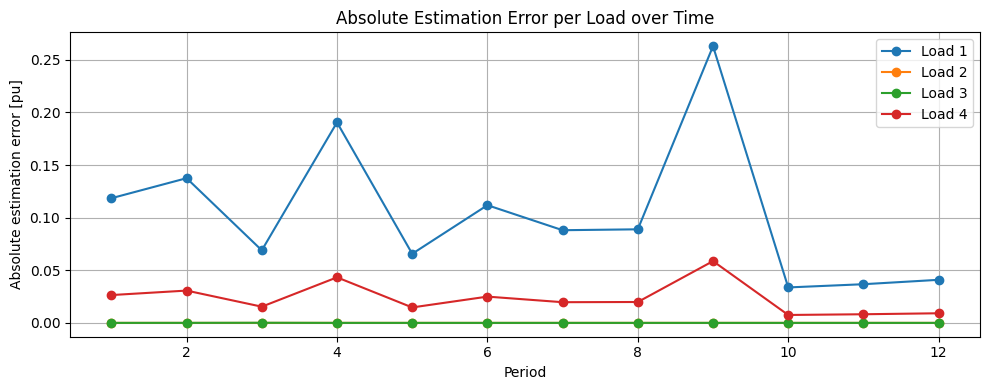

In [10]:
# Estimation errors
estimation_errors = ds - np.real(dx).T  # shape (m, 4)
abs_errors = np.abs(estimation_errors)

error_df = pd.DataFrame(
    abs_errors,
    columns=[f'Load {i+1}' for i in range(4)],
    index=[f'Period {i+1}' for i in range(m)]
)

# Force clean display in Jupyter
from IPython.display import display
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

print("=== Absolute Estimation Error per Load and Period ===")
display(error_df)

summary_df = pd.DataFrame({
    'Mean Abs Error': error_df.mean(),
    'Max Abs Error': error_df.max()
})
print("\n=== Summary Statistics ===")
display(summary_df)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(4):
    ax.plot(range(1, m+1), abs_errors[:, i], marker='o', label=f'Load {i+1}')
ax.set_xlabel('Period')
ax.set_ylabel('Absolute estimation error [pu]')
ax.set_title('Absolute Estimation Error per Load over Time')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

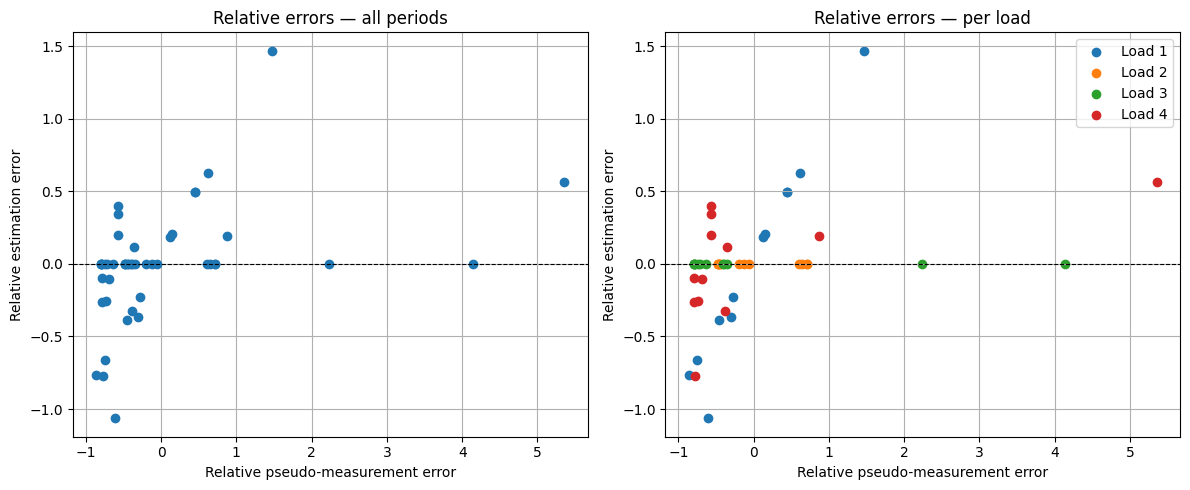


=== Mean Relative Estimation Error per Load ===
Load 1   0.5792
Load 2   0.0001
Load 3   0.0002
Load 4   0.3042


In [11]:
# Normalise by pseudo-measurements to get relative quantities
rel_pm_error = ds / sp                          # shape (m, 4)
rel_est_error = estimation_errors / sp          # shape (m, 4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(m):
    axes[0].plot(rel_pm_error[i, :], rel_est_error[i, :], 'C0o')
axes[0].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Relative pseudo-measurement error')
axes[0].set_ylabel('Relative estimation error')
axes[0].set_title('Relative errors — all periods')
axes[0].grid(True)

# Per-load view to see which loads drive the error
for i in range(4):
    axes[1].scatter(rel_pm_error[:, i], rel_est_error[:, i], label=f'Load {i+1}')
axes[1].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Relative pseudo-measurement error')
axes[1].set_ylabel('Relative estimation error')
axes[1].set_title('Relative errors — per load')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n=== Mean Relative Estimation Error per Load ===")
rel_err_df = pd.DataFrame(
    np.abs(rel_est_error),
    columns=[f'Load {i+1}' for i in range(4)],
    index=[f'Period {i+1}' for i in range(m)]
)
print(rel_err_df.mean().round(4).to_string())

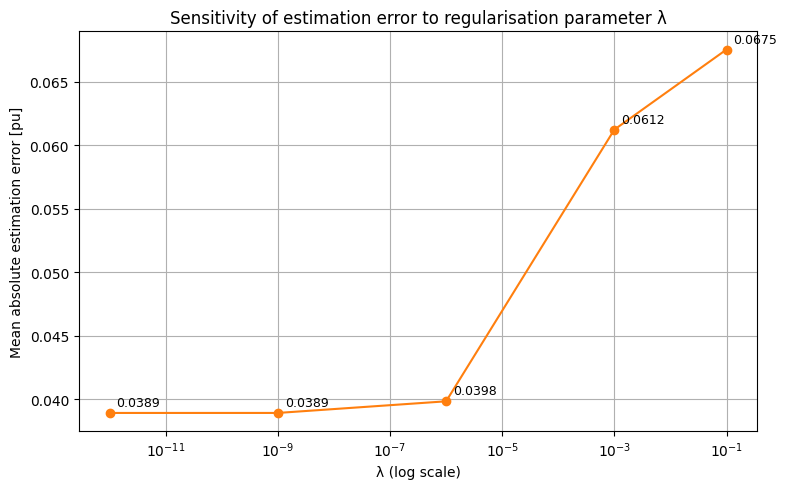


=== Mean Absolute Error by λ ===
  λ = 1e-12  →  MAE = 0.038921 pu
  λ = 1e-09  →  MAE = 0.038922 pu
  λ = 1e-06  →  MAE = 0.039838 pu
  λ = 1e-03  →  MAE = 0.061216 pu
  λ = 1e-01  →  MAE = 0.067520 pu


In [12]:
lambdas = [1e-12, 1e-9, 1e-6, 1e-3, 1e-1]
mean_abs_errors = []  # mean absolute error across all loads and periods for each λ

for lam_test in lambdas:
    dx_test = np.zeros((4, m), dtype=complex)

    for i in range(m):
        si_t = [
            [0, 0,       s[i, 2], 0       ],
            [0, 0,       s[i, 1], 0       ],
            [0, s[i, 0], 0,       s[i, 3] ],
        ]
        mvp_t, _ = pf3ph(topo, z, si_t, vr, el, ni, al)
        zv_t = mvp_t[:, 3]
        dv = zv_t - zv

        AtA = A.conj().T @ A
        Atdv = A.conj().T @ dv
        dx_test[:, i] = np.linalg.solve(AtA + lam_test * rhoTrho, Atdv)

    errs = ds - np.real(dx_test).T
    mean_abs_errors.append(np.mean(np.abs(errs)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(lambdas, mean_abs_errors, marker='o', color='C1')
ax.set_xlabel('λ (log scale)')
ax.set_ylabel('Mean absolute estimation error [pu]')
ax.set_title('Sensitivity of estimation error to regularisation parameter λ')
ax.grid(True, which='both')

for lam_val, err in zip(lambdas, mean_abs_errors):
    ax.annotate(f'{err:.4f}', (lam_val, err), textcoords="offset points",
                xytext=(5, 5), fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Mean Absolute Error by λ ===")
for lam_val, err in zip(lambdas, mean_abs_errors):
    print(f"  λ = {lam_val:.0e}  →  MAE = {err:.6f} pu")